Total Stocks: 2224
Loading cached data...
Processing indicators...
Usable Stocks: 901

========== RESULTS ==========
Total Trades: 2617

Initial Capital: 100000
Final Capital: 1370567.92
Total Return %: 1270.57

Long Profit: 706405.05
Short Profit: 508894.6

Win Rate %: 42.57
Average Win: 2637.0
Average Loss: -1145.92
Sharpe Ratio: 0.47
Max Drawdown %: -82.36
CAGR %: 29.92

Exit Reason Breakdown:
Exit Reason
UT Buy Cover    1641
UT Sell          465
Stop Loss        313
Drawdown         170
ATR Stop          28
Name: count, dtype: int64

Saved: trade_log.xlsx


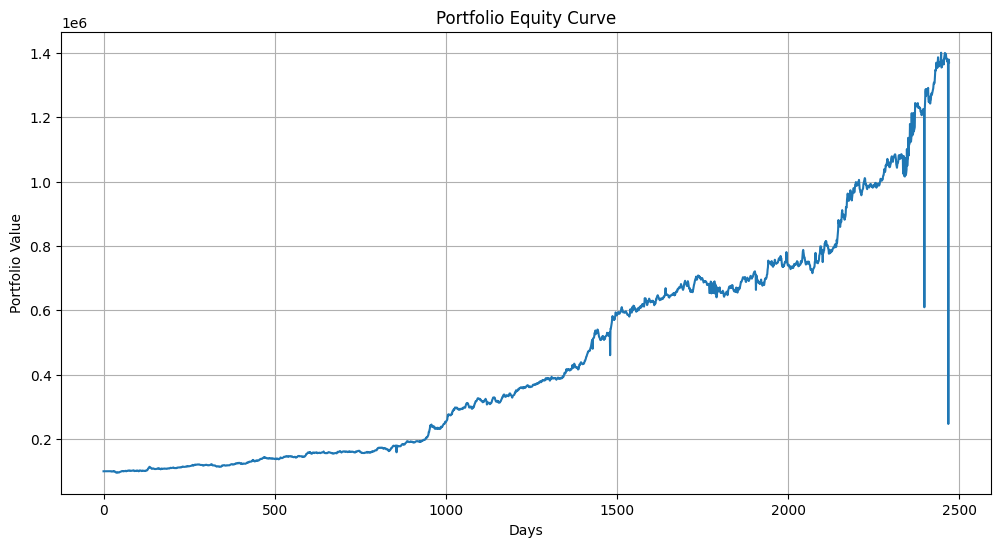


Generating Heatmap...


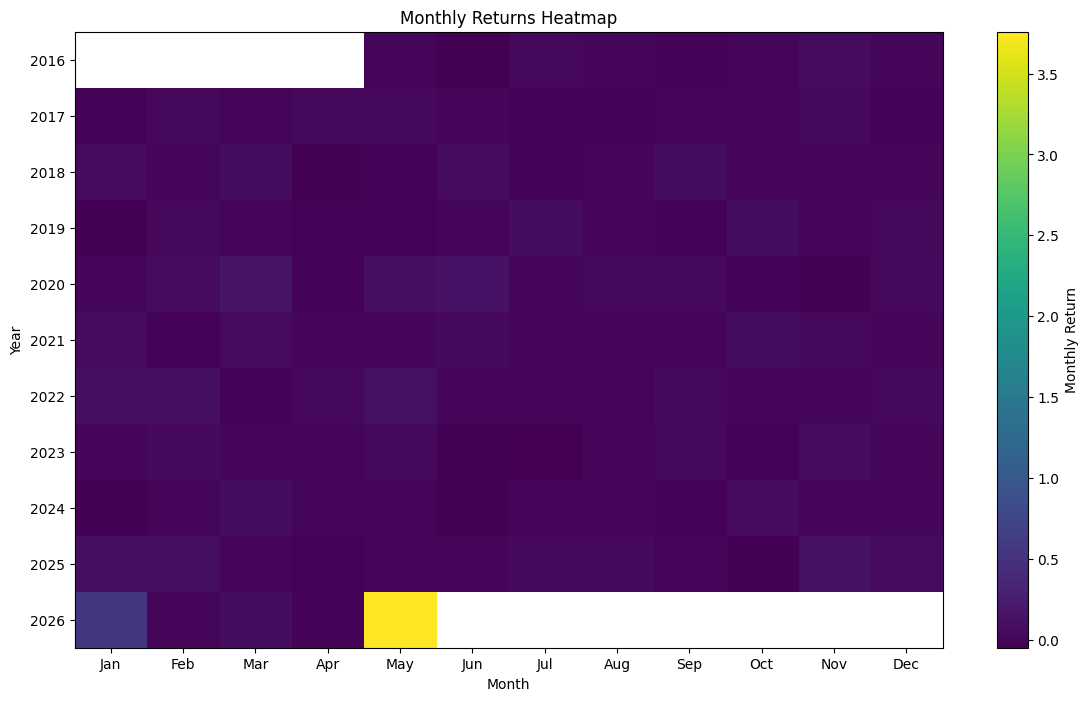

In [2]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from concurrent.futures import ThreadPoolExecutor

# ---------- SETTINGS ----------
initial_capital = 100000
cash = initial_capital

stop_loss_pct = 0.04
max_positions = 20
lookback_period = "10y"

atr_stop_multiplier = 4
max_drawdown_pct = 0.08

# NEW SETTINGS
graham_overvalued_pct = 1.30     # 30% overvalued for short
dip_buy_pct = 0.20               # average down at 10% fall
dip_buy_multiplier = 0.50        # add 50% more capital

CACHE_FILE = "price_cache.pkl"

trade_log = []
open_positions = {}

# ---------- LOAD NSE STOCKS ----------
def load_nse_tickers():

    df = pd.read_csv("data/EQUITY_L.csv")

    symbols = (
        df["SYMBOL"]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
        .tolist()
    )

    tickers = []

    for symbol in symbols:

        if "&" in symbol:
            continue

        tickers.append(symbol + ".NS")

    return tickers


tickers = load_nse_tickers()

print("Total Stocks:", len(tickers))


# ---------- DOWNLOAD / CACHE ----------
if os.path.exists(CACHE_FILE):

    print("Loading cached data...")

    price_data = pd.read_pickle(CACHE_FILE)

else:

    print("Downloading data...")

    price_data = yf.download(
        tickers,
        period=lookback_period,
        group_by="ticker",
        auto_adjust=True,
        threads=True
    )

    price_data.to_pickle(CACHE_FILE)

    print("Cache saved!")


# ---------- GRAHAM VALUE ----------
def graham_intrinsic_value(eps, growth):

    growth = max(min(growth, 20), 0)

    return eps * (8.5 + (2 * growth))


# ---------- PETER LYNCH VALUE ----------
def peter_lynch_value(eps, growth):

    growth = max(growth, 1)

    return eps * growth


# ---------- UT BOT ----------
def compute_utbot(df):

    df = df.copy()

    high = df["High"]
    low = df["Low"]
    close = df["Close"]

    tr = np.maximum(
        high - low,
        np.maximum(
            abs(high - close.shift()),
            abs(low - close.shift())
        )
    )

    df["atr"] = tr.rolling(14).mean()

    df["upper"] = close - df["atr"]
    df["lower"] = close + df["atr"]

    trend = [1]

    for i in range(1, len(df)):

        if close.iloc[i] > df["lower"].iloc[i - 1]:
            trend.append(1)

        elif close.iloc[i] < df["upper"].iloc[i - 1]:
            trend.append(-1)

        else:
            trend.append(trend[-1])

    df["trend"] = trend

    df["buy"] = (
        (df["trend"] == 1)
        &
        (df["trend"].shift() == -1)
    )

    df["sell"] = (
        (df["trend"] == -1)
        &
        (df["trend"].shift() == 1)
    )

    df["volatility"] = (
        close.pct_change()
        .rolling(20)
        .std()
    )

    return df


# ---------- PROCESS STOCK ----------
def process_ticker(ticker):

    try:

        df = price_data[ticker].dropna()

        if df.empty:
            return None

        stock = yf.Ticker(ticker)

        info = stock.info

        eps = info.get("trailingEps")

        if eps is None or eps <= 0:
            return None

        growth_raw = info.get("earningsQuarterlyGrowth")

        if growth_raw is None:
            growth = 10

        else:
            growth = growth_raw * 100

        graham_value = graham_intrinsic_value(
            eps,
            growth
        )

        lynch_value = peter_lynch_value(
            eps,
            growth
        )

        intrinsic = (
            graham_value + lynch_value
        ) / 2

        df["Intrinsic"] = intrinsic
        df["Graham"] = graham_value
        df["Lynch"] = lynch_value

        df = compute_utbot(df)

        return ticker, df

    except:
        return None


# ---------- PARALLEL PROCESSING ----------
print("Processing indicators...")

all_data = {}

with ThreadPoolExecutor(max_workers=8) as executor:

    results = executor.map(process_ticker, tickers)

for result in results:

    if result is not None:

        ticker, df = result

        all_data[ticker] = df

print("Usable Stocks:", len(all_data))


# ---------- MASTER DATE INDEX ----------
all_dates = sorted(
    set(date for df in all_data.values() for date in df.index)
)

equity_curve = []

short_profit_total = 0
long_profit_total = 0


# ---------- BACKTEST ----------
for current_date in all_dates:

    # ---------- EXIT ----------
    for ticker in list(open_positions.keys()):

        df = all_data[ticker]

        if current_date not in df.index:
            continue

        row = df.loc[current_date]

        pos = open_positions[ticker]

        trade_type = pos["type"]

        # ====================================
        # LONG POSITION
        # ====================================
        if trade_type == "LONG":

            pos["highest_price"] = max(
                pos["highest_price"],
                row["Close"]
            )

            # ---------- AVERAGE DOWN ----------
            drawdown_from_entry = (
                pos["entry_price"] - row["Close"]
            ) / pos["entry_price"]

            if (
                drawdown_from_entry >= dip_buy_pct
                and
                not pos["averaged_down"]
            ):

                extra_investment = (
                    pos["invested"]
                    * dip_buy_multiplier
                )

                if cash >= extra_investment:

                    extra_shares = (
                        extra_investment
                        / row["Close"]
                    )

                    total_cost = (
                        pos["invested"]
                        + extra_investment
                    )

                    total_shares = (
                        pos["shares"]
                        + extra_shares
                    )

                    avg_price = (
                        total_cost
                        / total_shares
                    )

                    pos["shares"] = total_shares
                    pos["invested"] = total_cost
                    pos["entry_price"] = avg_price

                    cash -= extra_investment

                    pos["averaged_down"] = True

            stop_price = (
                pos["entry_price"]
                * (1 - stop_loss_pct)
            )

            atr_stop = (
                pos["highest_price"]
                - (row["atr"] * atr_stop_multiplier)
            )

            drawdown = (
                pos["highest_price"]
                - row["Close"]
            ) / pos["highest_price"]

            if row["Close"] <= stop_price:

                exit_reason = "Stop Loss"

            elif row["Close"] <= atr_stop:

                exit_reason = "ATR Stop"

            elif drawdown >= max_drawdown_pct:

                exit_reason = "Drawdown"

            elif bool(row["sell"]):

                exit_reason = "UT Sell"

            else:
                continue

            exit_price = row["Close"]

            proceeds = pos["shares"] * exit_price

            profit = proceeds - pos["invested"]

            long_profit_total += profit

            cash += proceeds

        # ====================================
        # SHORT POSITION
        # ====================================
        else:

            if bool(row["buy"]):

                exit_reason = "UT Buy Cover"

            else:
                continue

            exit_price = row["Close"]

            profit = (
                pos["entry_price"]
                - exit_price
            ) * pos["shares"]

            short_profit_total += profit

            cash += (
                pos["invested"]
                + profit
            )

        # ---------- SAVE TRADE ----------
        trade_log.append({

            "Stock": ticker,

            "Type": trade_type,

            "Entry Date": pos["entry_date"],
            "Exit Date": current_date,

            "Entry": pos["entry_price"],
            "Exit": exit_price,

            "Profit": profit,

            "Return %": (
                (
                    exit_price
                    /
                    pos["entry_price"]
                ) - 1
            ) * 100
            if trade_type == "LONG"
            else
            (
                (
                    pos["entry_price"]
                    - exit_price
                )
                /
                pos["entry_price"]
            ) * 100,

            "Exit Reason": exit_reason
        })

        del open_positions[ticker]

    # ---------- BUY / SHORT ----------
    available_slots = (
        max_positions - len(open_positions)
    )

    if available_slots > 0:

        candidates = []

        for ticker, df in all_data.items():

            if ticker in open_positions:
                continue

            if current_date not in df.index:
                continue

            row = df.loc[current_date]

            if pd.isna(row["volatility"]):
                continue

            if row["volatility"] == 0:
                continue

            # ====================================
            # LONG ENTRY
            # ====================================
            if (
                bool(row["buy"])
                and
                row["Close"] < row["Graham"]
                and
                row["Close"] < row["Lynch"]
            ):

                discount = (
                    row["Intrinsic"]
                    - row["Close"]
                ) / row["Intrinsic"]

                score = (
                    discount
                    /
                    row["volatility"]
                )

                candidates.append((
                    ticker,
                    "LONG",
                    score
                ))

            # ====================================
            # SHORT ENTRY
            # ====================================
            elif (
                bool(row["sell"])
                and
                row["Close"] >
                (row["Graham"] * graham_overvalued_pct)
            ):

                overvaluation = (
                    row["Close"]
                    - row["Graham"]
                ) / row["Graham"]

                score = (
                    overvaluation
                    /
                    row["volatility"]
                )

                candidates.append((
                    ticker,
                    "SHORT",
                    score
                ))

        candidates.sort(
            key=lambda x: x[2],
            reverse=True
        )

        for ticker, trade_type, score in candidates[:available_slots]:

            df = all_data[ticker]

            row = df.loc[current_date]

            allocation = (
                cash
                /
                (max_positions - len(open_positions))
            )

            if allocation <= 0:
                break

            shares = allocation / row["Close"]

            cash -= allocation

            open_positions[ticker] = {

                "type": trade_type,

                "entry_date": current_date,

                "entry_price": row["Close"],

                "highest_price": row["Close"],

                "shares": shares,

                "invested": allocation,

                "averaged_down": False
            }

    # ---------- EQUITY ----------
    portfolio_value = cash

    for ticker, pos in open_positions.items():

        df = all_data[ticker]

        if current_date in df.index:

            current_price = df.loc[current_date]["Close"]

            if pos["type"] == "LONG":

                portfolio_value += (
                    pos["shares"]
                    * current_price
                )

            else:

                short_pnl = (
                    pos["entry_price"]
                    - current_price
                ) * pos["shares"]

                portfolio_value += (
                    pos["invested"]
                    + short_pnl
                )

    equity_curve.append(portfolio_value)


# ---------- RESULTS ----------
trades = pd.DataFrame(trade_log)

print("\n========== RESULTS ==========")

print("Total Trades:", len(trades))

final_capital = equity_curve[-1]

total_return = (
    (final_capital / initial_capital) - 1
) * 100

print("\nInitial Capital:", round(initial_capital, 2))
print("Final Capital:", round(final_capital, 2))
print("Total Return %:", round(total_return, 2))

print("\nLong Profit:", round(long_profit_total, 2))
print("Short Profit:", round(short_profit_total, 2))


# ---------- PERFORMANCE ----------
if not trades.empty:

    wins = trades[trades["Profit"] > 0]
    losses = trades[trades["Profit"] <= 0]

    win_rate = (
        len(wins)
        /
        len(trades)
    ) * 100

    avg_win = (
        wins["Profit"].mean()
        if len(wins) > 0 else 0
    )

    avg_loss = (
        losses["Profit"].mean()
        if len(losses) > 0 else 0
    )

    print("\nWin Rate %:", round(win_rate, 2))
    print("Average Win:", round(avg_win, 2))
    print("Average Loss:", round(avg_loss, 2))

    # ---------- SHARPE ----------
    equity_series = pd.Series(equity_curve)

    daily_returns = (
        equity_series
        .pct_change()
        .dropna()
    )

    if daily_returns.std() != 0:

        sharpe_ratio = (
            daily_returns.mean()
            /
            daily_returns.std()
        ) * np.sqrt(252)

    else:
        sharpe_ratio = 0

    print("Sharpe Ratio:", round(sharpe_ratio, 2))

    # ---------- MAX DRAWDOWN ----------
    rolling_max = equity_series.cummax()

    drawdowns = (
        equity_series - rolling_max
    ) / rolling_max

    max_dd = drawdowns.min() * 100

    print("Max Drawdown %:", round(max_dd, 2))

    # ---------- CAGR ----------
    years = 10

    cagr = (
        (
            final_capital
            /
            initial_capital
        ) ** (1 / years) - 1
    ) * 100

    print("CAGR %:", round(cagr, 2))

    # ---------- EXIT REASONS ----------
    print("\nExit Reason Breakdown:")
    print(trades["Exit Reason"].value_counts())

    # ---------- REMOVE TIMEZONE ----------
    for col in ["Entry Date", "Exit Date"]:

        trades[col] = pd.to_datetime(
            trades[col]
        ).dt.tz_localize(None)

    # ---------- SAVE ----------
    trades.to_excel(
        "trade_log.xlsx",
        index=False
    )

    print("\nSaved: trade_log.xlsx")


# ---------- EQUITY CURVE ----------
plt.figure(figsize=(12, 6))

plt.plot(equity_curve)

plt.title(
    "Portfolio Equity Curve"
)

plt.xlabel("Days")

plt.ylabel("Portfolio Value")

plt.grid(True)

plt.show()


# ---------- MONTHLY RETURNS HEATMAP ----------
if len(equity_curve) > 30:

    print("\nGenerating Heatmap...")

    equity_df = pd.DataFrame({
        "Date": all_dates[:len(equity_curve)],
        "Equity": equity_curve
    })

    equity_df["Date"] = pd.to_datetime(
        equity_df["Date"]
    )

    equity_df["Month"] = (
        equity_df["Date"].dt.month
    )

    equity_df["Year"] = (
        equity_df["Date"].dt.year
    )

    equity_df["Returns"] = (
        equity_df["Equity"]
        .pct_change()
    )

    monthly_returns = (
        equity_df
        .groupby(["Year", "Month"])["Returns"]
        .sum()
        .unstack()
    )

    plt.figure(figsize=(14, 8))

    plt.imshow(
        monthly_returns,
        aspect='auto'
    )

    plt.colorbar(
        label="Monthly Return"
    )

    plt.xticks(
        range(12),
        [
            "Jan", "Feb", "Mar",
            "Apr", "May", "Jun",
            "Jul", "Aug", "Sep",
            "Oct", "Nov", "Dec"
        ]
    )

    plt.yticks(
        range(len(monthly_returns.index)),
        monthly_returns.index
    )

    plt.title(
        "Monthly Returns Heatmap"
    )

    plt.xlabel("Month")

    plt.ylabel("Year")

    plt.show()

Total Stocks: 2224
Loading cached data...
Processing indicators...


HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}
HTTP Error 401: {"finance":{"result":null,"error":{"code":"Unauthorized","description":"Invalid Crumb"}}}


Usable Stocks: 1628

========== RESULTS ==========
Total Trades: 1097

Initial Capital: 100000
Final Capital: 858639.35
Total Return %: 758.64

Long Profit: 347084.34
Short Profit: 433325.51

Win Rate %: 44.67
Average Win: 4845.13
Average Loss: -2625.54
Sharpe Ratio: 0.56
Max Drawdown %: -66.31
CAGR %: 23.99

Exit Reason Breakdown:
Exit Reason
UT Buy Cover    829
Drawdown        194
ATR Stop         39
UT Sell          34
Stop Loss         1
Name: count, dtype: int64

Saved: trade_log.xlsx


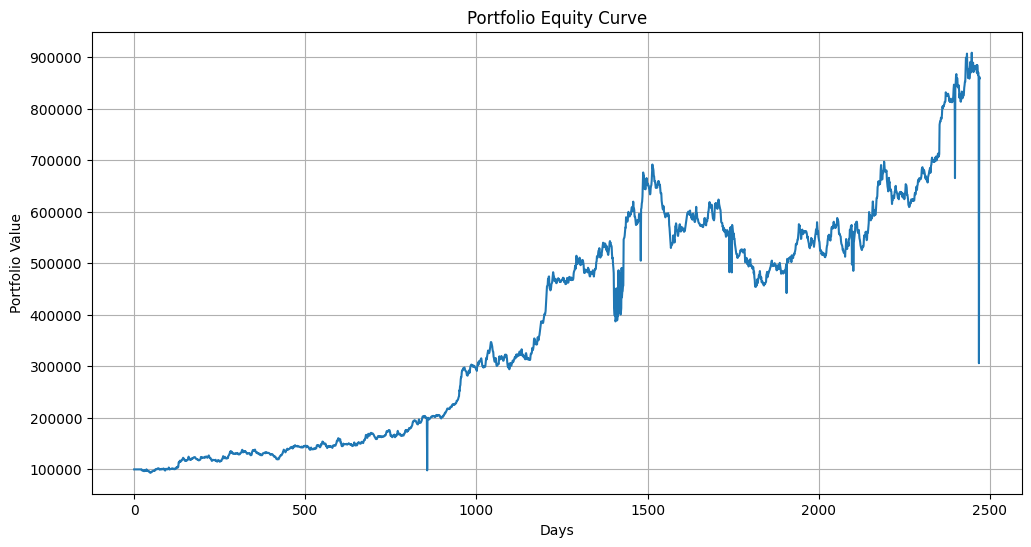


Generating Heatmap...


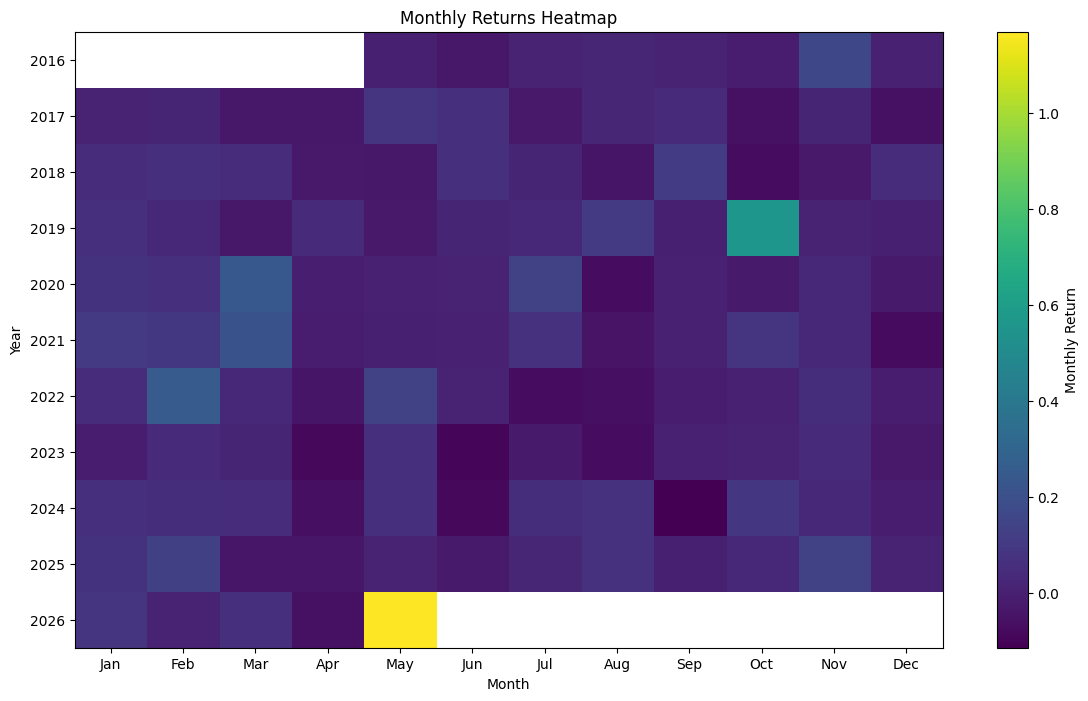

In [13]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from concurrent.futures import ThreadPoolExecutor

# ---------- SETTINGS ----------
initial_capital = 100000
cash = initial_capital

stop_loss_pct = 0.07
max_positions = 8
lookback_period = "10y"

atr_stop_multiplier = 2
max_drawdown_pct = 0.03

# NEW SETTINGS
graham_overvalued_pct = 1.80
dip_buy_pct = 0.10
dip_buy_multiplier = 0.01

CACHE_FILE = "price_cache.pkl"

trade_log = []
open_positions = {}

# ---------- LOAD NSE STOCKS ----------
def load_nse_tickers():

    df = pd.read_csv("data/EQUITY_L.csv")

    symbols = (
        df["SYMBOL"]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
        .tolist()
    )

    tickers = []

    for symbol in symbols:

        if "&" in symbol:
            continue

        tickers.append(symbol + ".NS")

    return tickers


tickers = load_nse_tickers()

print("Total Stocks:", len(tickers))


# ---------- DOWNLOAD / CACHE ----------
if os.path.exists(CACHE_FILE):

    print("Loading cached data...")

    price_data = pd.read_pickle(CACHE_FILE)

else:

    print("Downloading data...")

    price_data = yf.download(
        tickers,
        period=lookback_period,
        group_by="ticker",
        auto_adjust=True,
        threads=True
    )

    price_data.to_pickle(CACHE_FILE)

    print("Cache saved!")


# ---------- GRAHAM VALUE ----------
def graham_intrinsic_value(eps, growth):

    growth = max(min(growth, 20), 0)

    return eps * (8.5 + (2 * growth))


# ---------- PETER LYNCH VALUE ----------
def peter_lynch_value(eps, growth):

    growth = max(growth, 1)

    return eps * growth


# ---------- UT BOT ----------
def compute_utbot(df):

    df = df.copy()

    high = df["High"]
    low = df["Low"]
    close = df["Close"]

    tr = np.maximum(
        high - low,
        np.maximum(
            abs(high - close.shift()),
            abs(low - close.shift())
        )
    )

    df["atr"] = tr.rolling(14).mean()

    df["upper"] = close - df["atr"]
    df["lower"] = close + df["atr"]

    trend = [1]

    for i in range(1, len(df)):

        if close.iloc[i] > df["lower"].iloc[i - 1]:
            trend.append(1)

        elif close.iloc[i] < df["upper"].iloc[i - 1]:
            trend.append(-1)

        else:
            trend.append(trend[-1])

    df["trend"] = trend

    df["buy"] = (
        (df["trend"] == 1)
        &
        (df["trend"].shift() == -1)
    )

    df["sell"] = (
        (df["trend"] == -1)
        &
        (df["trend"].shift() == 1)
    )

    df["volatility"] = (
        close.pct_change()
        .rolling(20)
        .std()
    )

    return df


# ---------- PROCESS STOCK ----------
def process_ticker(ticker):

    try:

        df = price_data[ticker].dropna()

        if df.empty:
            return None

        stock = yf.Ticker(ticker)

        info = stock.info

        eps = info.get("trailingEps")

        if eps is None or eps <= 0:
            return None

        growth_raw = info.get("earningsQuarterlyGrowth")

        if growth_raw is None:
            growth = 10

        else:
            growth = growth_raw * 100

        graham_value = graham_intrinsic_value(
            eps,
            growth
        )

        lynch_value = peter_lynch_value(
            eps,
            growth
        )

        intrinsic = (
            graham_value + lynch_value
        ) / 2

        df["Intrinsic"] = intrinsic
        df["Graham"] = graham_value
        df["Lynch"] = lynch_value

        df = compute_utbot(df)

        return ticker, df

    except:
        return None


# ---------- PARALLEL PROCESSING ----------
print("Processing indicators...")

all_data = {}

with ThreadPoolExecutor(max_workers=8) as executor:

    results = executor.map(process_ticker, tickers)

for result in results:

    if result is not None:

        ticker, df = result

        all_data[ticker] = df

print("Usable Stocks:", len(all_data))


# ---------- MASTER DATE INDEX ----------
all_dates = sorted(
    set(date for df in all_data.values() for date in df.index)
)

equity_curve = []

short_profit_total = 0
long_profit_total = 0


# ---------- BACKTEST ----------
for current_date in all_dates:

    # ---------- EXIT ----------
    for ticker in list(open_positions.keys()):

        df = all_data[ticker]

        if current_date not in df.index:
            continue

        row = df.loc[current_date]

        pos = open_positions[ticker]

        trade_type = pos["type"]

        # ---------- LONG ----------
        if trade_type == "LONG":

            pos["highest_price"] = max(
                pos["highest_price"],
                row["Close"]
            )

            # ---------- AVERAGE DOWN ----------
            drawdown_from_entry = (
                pos["entry_price"] - row["Close"]
            ) / pos["entry_price"]

            if (
                drawdown_from_entry >= dip_buy_pct
                and
                not pos["averaged_down"]
            ):

                extra_investment = (
                    pos["invested"]
                    * dip_buy_multiplier
                )

                if cash >= extra_investment:

                    extra_shares = (
                        extra_investment
                        / row["Close"]
                    )

                    total_cost = (
                        pos["invested"]
                        + extra_investment
                    )

                    total_shares = (
                        pos["shares"]
                        + extra_shares
                    )

                    avg_price = (
                        total_cost
                        / total_shares
                    )

                    pos["shares"] = total_shares
                    pos["invested"] = total_cost
                    pos["entry_price"] = avg_price

                    cash -= extra_investment

                    pos["averaged_down"] = True

            stop_price = (
                pos["entry_price"]
                * (1 - stop_loss_pct)
            )

            atr_stop = (
                pos["highest_price"]
                - (row["atr"] * atr_stop_multiplier)
            )

            drawdown = (
                pos["highest_price"]
                - row["Close"]
            ) / pos["highest_price"]

            if row["Close"] <= stop_price:

                exit_reason = "Stop Loss"

            elif row["Close"] <= atr_stop:

                exit_reason = "ATR Stop"

            elif drawdown >= max_drawdown_pct:

                exit_reason = "Drawdown"

            elif bool(row["sell"]):

                exit_reason = "UT Sell"

            else:
                continue

            exit_price = row["Close"]

            proceeds = pos["shares"] * exit_price

            profit = proceeds - pos["invested"]

            long_profit_total += profit

            cash += proceeds

        # ---------- SHORT ----------
        else:

            if bool(row["buy"]):

                exit_reason = "UT Buy Cover"

            else:
                continue

            exit_price = row["Close"]

            profit = (
                pos["entry_price"]
                - exit_price
            ) * pos["shares"]

            short_profit_total += profit

            cash += (
                pos["invested"]
                + profit
            )

        # ---------- SAVE TRADE ----------
        trade_log.append({

            "Stock": ticker,

            "Type": trade_type,

            "Entry Date": pos["entry_date"],
            "Exit Date": current_date,

            "Entry": pos["entry_price"],
            "Exit": exit_price,

            "Profit": profit,

            "Return %": (
                (
                    exit_price
                    /
                    pos["entry_price"]
                ) - 1
            ) * 100
            if trade_type == "LONG"
            else
            (
                (
                    pos["entry_price"]
                    - exit_price
                )
                /
                pos["entry_price"]
            ) * 100,

            "Exit Reason": exit_reason
        })

        del open_positions[ticker]

    # ---------- BUY / SHORT ----------
    available_slots = (
        max_positions - len(open_positions)
    )

    if available_slots > 0:

        candidates = []

        for ticker, df in all_data.items():

            if ticker in open_positions:
                continue

            if current_date not in df.index:
                continue

            row = df.loc[current_date]

            if pd.isna(row["volatility"]):
                continue

            if row["volatility"] == 0:
                continue

            # ---------- LONG ENTRY ----------
            if (
                bool(row["buy"])
                and
                row["Close"] < row["Graham"]
                and
                row["Close"] < row["Lynch"]
            ):

                discount = (
                    row["Intrinsic"]
                    - row["Close"]
                ) / row["Intrinsic"]

                score = (
                    discount
                    /
                    row["volatility"]
                )

                candidates.append((
                    ticker,
                    "LONG",
                    score
                ))

            # ---------- SHORT ENTRY ----------
            elif (
                bool(row["sell"])
                and
                row["Close"] >
                (row["Graham"] * graham_overvalued_pct)
            ):

                overvaluation = (
                    row["Close"]
                    - row["Graham"]
                ) / row["Graham"]

                score = (
                    overvaluation
                    /
                    row["volatility"]
                )

                candidates.append((
                    ticker,
                    "SHORT",
                    score
                ))

        candidates.sort(
            key=lambda x: x[2],
            reverse=True
        )

        for ticker, trade_type, score in candidates[:available_slots]:

            df = all_data[ticker]

            row = df.loc[current_date]

            allocation = (
                cash
                /
                (max_positions - len(open_positions))
            )

            if allocation <= 0:
                break

            shares = allocation / row["Close"]

            cash -= allocation

            open_positions[ticker] = {

                "type": trade_type,

                "entry_date": current_date,

                "entry_price": row["Close"],

                "highest_price": row["Close"],

                "shares": shares,

                "invested": allocation,

                "averaged_down": False
            }

    # ---------- EQUITY ----------
    portfolio_value = cash

    for ticker, pos in open_positions.items():

        df = all_data[ticker]

        if current_date in df.index:

            current_price = df.loc[current_date]["Close"]

            if pos["type"] == "LONG":

                portfolio_value += (
                    pos["shares"]
                    * current_price
                )

            else:

                short_pnl = (
                    pos["entry_price"]
                    - current_price
                ) * pos["shares"]

                portfolio_value += (
                    pos["invested"]
                    + short_pnl
                )

    equity_curve.append(portfolio_value)


# ---------- RESULTS ----------
trades = pd.DataFrame(trade_log)

print("\n========== RESULTS ==========")

print("Total Trades:", len(trades))

final_capital = equity_curve[-1]

total_return = (
    (final_capital / initial_capital) - 1
) * 100

print("\nInitial Capital:", round(initial_capital, 2))
print("Final Capital:", round(final_capital, 2))
print("Total Return %:", round(total_return, 2))

print("\nLong Profit:", round(long_profit_total, 2))
print("Short Profit:", round(short_profit_total, 2))


# ---------- PERFORMANCE ----------
if not trades.empty:

    wins = trades[trades["Profit"] > 0]
    losses = trades[trades["Profit"] <= 0]

    win_rate = (
        len(wins)
        /
        len(trades)
    ) * 100

    avg_win = (
        wins["Profit"].mean()
        if len(wins) > 0 else 0
    )

    avg_loss = (
        losses["Profit"].mean()
        if len(losses) > 0 else 0
    )

    print("\nWin Rate %:", round(win_rate, 2))
    print("Average Win:", round(avg_win, 2))
    print("Average Loss:", round(avg_loss, 2))

    # ---------- SHARPE ----------
    equity_series = pd.Series(equity_curve)

    daily_returns = (
        equity_series
        .pct_change()
        .dropna()
    )

    if daily_returns.std() != 0:

        sharpe_ratio = (
            daily_returns.mean()
            /
            daily_returns.std()
        ) * np.sqrt(252)

    else:
        sharpe_ratio = 0

    print("Sharpe Ratio:", round(sharpe_ratio, 2))

    # ---------- MAX DRAWDOWN ----------
    rolling_max = equity_series.cummax()

    drawdowns = (
        equity_series - rolling_max
    ) / rolling_max

    max_dd = drawdowns.min() * 100

    print("Max Drawdown %:", round(max_dd, 2))

    # ---------- CAGR ----------
    years = 10

    cagr = (
        (
            final_capital
            /
            initial_capital
        ) ** (1 / years) - 1
    ) * 100

    print("CAGR %:", round(cagr, 2))

    # ---------- EXIT REASONS ----------
    print("\nExit Reason Breakdown:")
    print(trades["Exit Reason"].value_counts())

    # ---------- REMOVE TIMEZONE ----------
    for col in ["Entry Date", "Exit Date"]:

        trades[col] = pd.to_datetime(
            trades[col]
        ).dt.tz_localize(None)

    # ---------- ADD CUMULATIVE PROFIT ----------
    trades["Cumulative Profit"] = (
        trades["Profit"].cumsum()
    )

    # ---------- ADD EQUITY ----------
    trades["Equity"] = (
        initial_capital
        + trades["Cumulative Profit"]
    )

    # ---------- SAVE ----------
    trades.to_excel(
        "trade_log.xlsx",
        index=False
    )

    print("\nSaved: trade_log.xlsx")


# ---------- EQUITY CURVE ----------
plt.figure(figsize=(12, 6))

plt.plot(equity_curve)

plt.title("Portfolio Equity Curve")

plt.xlabel("Days")

plt.ylabel("Portfolio Value")

plt.grid(True)

plt.show()


# ---------- MONTHLY RETURNS HEATMAP ----------
if len(equity_curve) > 30:

    print("\nGenerating Heatmap...")

    equity_df = pd.DataFrame({
        "Date": all_dates[:len(equity_curve)],
        "Equity": equity_curve
    })

    equity_df["Date"] = pd.to_datetime(
        equity_df["Date"]
    )

    equity_df["Month"] = (
        equity_df["Date"].dt.month
    )

    equity_df["Year"] = (
        equity_df["Date"].dt.year
    )

    equity_df["Returns"] = (
        equity_df["Equity"]
        .pct_change()
    )

    monthly_returns = (
        equity_df
        .groupby(["Year", "Month"])["Returns"]
        .sum()
        .unstack()
    )

    plt.figure(figsize=(14, 8))

    plt.imshow(
        monthly_returns,
        aspect='auto'
    )

    plt.colorbar(
        label="Monthly Return"
    )

    plt.xticks(
        range(12),
        [
            "Jan", "Feb", "Mar",
            "Apr", "May", "Jun",
            "Jul", "Aug", "Sep",
            "Oct", "Nov", "Dec"
        ]
    )

    plt.yticks(
        range(len(monthly_returns.index)),
        monthly_returns.index
    )

    plt.title(
        "Monthly Returns Heatmap"
    )

    plt.xlabel("Month")

    plt.ylabel("Year")

    plt.show()

Usable Stocks: 155


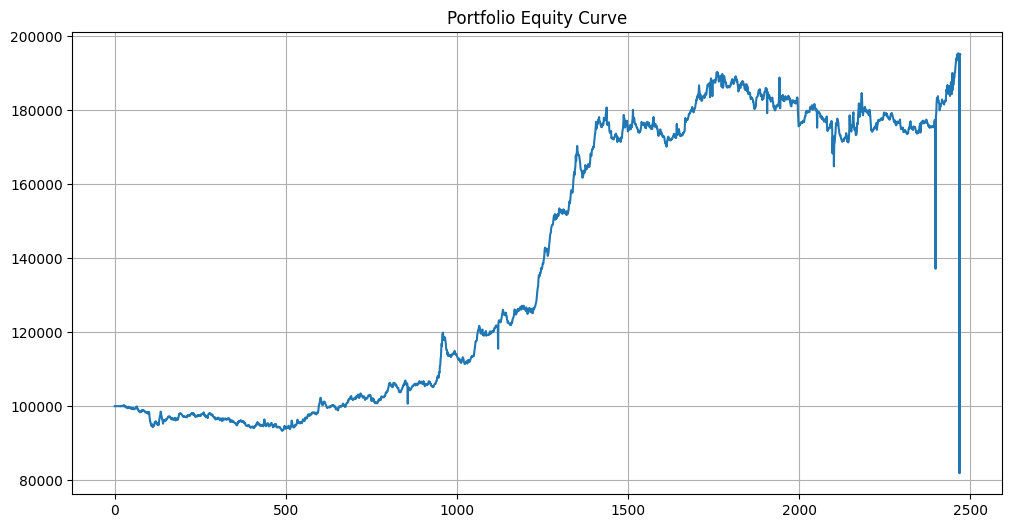

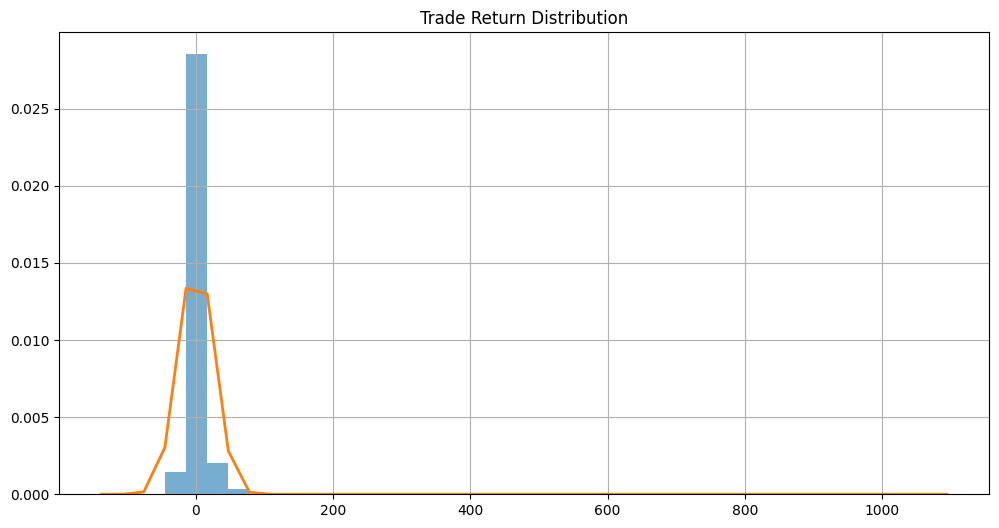

Finished Backtest


In [1]:
# Fully Updated NSE Backtest System


import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

# ---------- SETTINGS ----------
INITIAL_CAPITAL = 100000
STOP_LOSS_PCT = 0.04
MAX_POSITIONS = 30
LOOKBACK_PERIOD = "10y"
AVERAGE_DOWN_PCT = 0.10
SHORT_OVERVALUED_PCT = 0.30
CACHE_FILE = "price_cache.pkl"

cash = INITIAL_CAPITAL
trade_log = []
open_positions = {}

# ---------- LOAD NSE STOCKS ----------
def load_nse_tickers():
    df = pd.read_csv("data/EQUITY_L.csv")
    symbols = (
        df["SYMBOL"]
        .dropna()
        .astype(str)
        .str.strip()
        .unique()
        .tolist()
    )

    return [s + ".NS" for s in symbols if "&" not in s]

# ---------- UT BOT ----------
def compute_utbot(df):

    df = df.copy()

    high = df["High"]
    low = df["Low"]
    close = df["Close"]

    tr = np.maximum(
        high - low,
        np.maximum(
            abs(high - close.shift()),
            abs(low - close.shift())
        )
    )

    df["atr"] = tr.rolling(14).mean()

    df["upper"] = close - df["atr"]
    df["lower"] = close + df["atr"]

    trend = [1]

    for i in range(1, len(df)):

        if close.iloc[i] > df["lower"].iloc[i - 1]:
            trend.append(1)

        elif close.iloc[i] < df["upper"].iloc[i - 1]:
            trend.append(-1)

        else:
            trend.append(trend[-1])

    df["trend"] = trend

    df["buy"] = (
        (df["trend"] == 1)
        &
        (df["trend"].shift() == -1)
    )

    df["sell"] = (
        (df["trend"] == -1)
        &
        (df["trend"].shift() == 1)
    )

    return df

# ---------- GRAHAM ----------
def graham_value(eps, growth):
    growth = min(growth, 15)
    return eps * (8.5 + 2 * growth)

# ---------- PETER LYNCH ----------
def lynch_value(eps_growth, pe):
    if pe <= 0:
        return 0
    return eps_growth / pe

# ---------- DOWNLOAD ----------
tickers = load_nse_tickers()

if os.path.exists(CACHE_FILE):
    price_data = pd.read_pickle(CACHE_FILE)
else:
    price_data = yf.download(
        tickers,
        period=LOOKBACK_PERIOD,
        group_by="ticker",
        auto_adjust=True,
        threads=True
    )
    price_data.to_pickle(CACHE_FILE)

# ---------- PROCESS ----------
all_data = {}
fundamental_data = {}

for ticker in tickers:

    try:

        df = price_data[ticker].dropna()

        if df.empty:
            continue

        stock = yf.Ticker(ticker)
        info = stock.info

        eps = info.get("trailingEps")
        pe = info.get("trailingPE")
        growth = info.get("earningsQuarterlyGrowth")

        if eps is None or growth is None or pe is None:
            continue

        growth_pct = growth * 100

        intrinsic = graham_value(eps, growth_pct)

        lynch = lynch_value(growth_pct, pe)

        df = compute_utbot(df)

        all_data[ticker] = df

        fundamental_data[ticker] = {
            "intrinsic": intrinsic,
            "lynch": lynch
        }

    except:
        continue

print("Usable Stocks:", len(all_data))

all_dates = sorted(
    set(date for df in all_data.values() for date in df.index)
)

equity_curve = []

# ---------- BACKTEST ----------
for current_date in all_dates:

    # ---------- EXIT ----------
    for ticker in list(open_positions.keys()):

        df = all_data[ticker]

        if current_date not in df.index:
            continue

        row = df.loc[current_date]
        pos = open_positions[ticker]

        exit_trade = False

        # LONG EXIT
        if pos["type"] == "LONG":

            if row["sell"]:
                exit_trade = True

            elif row["Close"] <= pos["entry_price"] * (1 - STOP_LOSS_PCT):
                exit_trade = True

            if exit_trade:

                proceeds = pos["shares"] * row["Close"]
                profit = proceeds - pos["invested"]
                cash += proceeds

        # SHORT EXIT
        else:

            if row["buy"]:

                exit_trade = True

                profit = (
                    pos["entry_price"] - row["Close"]
                ) * pos["shares"]

                cash += pos["invested"] + profit

        if exit_trade:

            trade_log.append({
                "Stock": ticker,
                "Type": pos["type"],
                "Entry Date": pos["entry_date"],
                "Exit Date": current_date,
                "Entry": pos["entry_price"],
                "Exit": row["Close"],
                "Profit": profit,
                "Return %": (profit / pos["invested"]) * 100
            })

            del open_positions[ticker]

    # ---------- ENTRY ----------
    for ticker, df in all_data.items():

        if ticker in open_positions:
            continue

        if current_date not in df.index:
            continue

        row = df.loc[current_date]

        intrinsic = fundamental_data[ticker]["intrinsic"]
        lynch = fundamental_data[ticker]["lynch"]

        allocation = cash / max(1, MAX_POSITIONS)

        if allocation <= 0:
            continue

        # ---------- LONG ----------
        if (
            row["buy"]
            and row["Close"] < intrinsic
            and lynch > 1
        ):

            shares = allocation / row["Close"]

            open_positions[ticker] = {
                "type": "LONG",
                "entry_date": current_date,
                "entry_price": row["Close"],
                "shares": shares,
                "invested": allocation,
                "averaged": False
            }

            cash -= allocation

        # ---------- SHORT ----------
        elif (
            row["sell"]
            and row["Close"] > intrinsic * (1 + SHORT_OVERVALUED_PCT)
        ):

            shares = allocation / row["Close"]

            open_positions[ticker] = {
                "type": "SHORT",
                "entry_date": current_date,
                "entry_price": row["Close"],
                "shares": shares,
                "invested": allocation
            }

            cash -= allocation

    # ---------- AVERAGE DOWN ----------
    for ticker, pos in open_positions.items():

        if pos["type"] != "LONG":
            continue

        df = all_data[ticker]

        if current_date not in df.index:
            continue

        row = df.loc[current_date]

        drop_pct = (
            pos["entry_price"] - row["Close"]
        ) / pos["entry_price"]

        if drop_pct >= AVERAGE_DOWN_PCT and not pos["averaged"]:

            extra = pos["invested"] * 0.5

            if cash >= extra:

                extra_shares = extra / row["Close"]

                pos["shares"] += extra_shares
                pos["invested"] += extra
                pos["averaged"] = True

                cash -= extra

    # ---------- EQUITY ----------
    equity = cash

    for ticker, pos in open_positions.items():

        df = all_data[ticker]

        if current_date not in df.index:
            continue

        row = df.loc[current_date]

        if pos["type"] == "LONG":
            equity += pos["shares"] * row["Close"]

        else:
            unrealized = (
                pos["entry_price"] - row["Close"]
            ) * pos["shares"]

            equity += pos["invested"] + unrealized

    equity_curve.append(equity)

# ---------- RESULTS ----------
trades = pd.DataFrame(trade_log)

if not trades.empty:

    trades["Entry Date"] = pd.to_datetime(trades["Entry Date"]).dt.tz_localize(None)
    trades["Exit Date"] = pd.to_datetime(trades["Exit Date"]).dt.tz_localize(None)

    trades["Cumulative Profit"] = trades["Profit"].cumsum()

    trades["Equity"] = (
        INITIAL_CAPITAL
        + trades["Cumulative Profit"]
    )

    trades.to_excel("trade_log.xlsx", index=False)

# ---------- EQUITY CURVE ----------
plt.figure(figsize=(12, 6))
plt.plot(equity_curve)
plt.title("Portfolio Equity Curve")
plt.grid(True)
plt.show()

# ---------- NORMAL DISTRIBUTION ----------
if not trades.empty:

    plt.figure(figsize=(12, 6))

    returns = trades["Return %"].dropna()

    mean = returns.mean()
    std = returns.std()

    count, bins, ignored = plt.hist(
        returns,
        bins=40,
        density=True,
        alpha=0.6
    )

    normal = (
        1 / (std * np.sqrt(2 * np.pi))
    ) * np.exp(
        -((bins - mean) ** 2) / (2 * std ** 2)
    )

    plt.plot(bins, normal, linewidth=2)

    plt.title("Trade Return Distribution")
    plt.grid(True)
    plt.show()
  
print("Finished Backtest")